# MCTS Drug Design Testing Notebook

Testing the Monte Carlo Tree Search (MCTS) module for de novo drug design using R-BRICS fragments.
This notebook demonstrates how to:
- Load fragment libraries
- Configure the MCTS engine with custom scoring functions
- Generate molecular candidates
- Analyze and visualize the results

## 1. Import Required Libraries

Import necessary libraries including pandas, NumPy, RDKit, and the MCTSDrugDesign class with make_composite_scorer.

In [1]:
import pandas as pd
from collections import Counter,defaultdict
import matplotlib.pyplot as plt
import seaborn as sns
import logging
from pathlib import Path
import pyarrow as pa
from joblib import Parallel, delayed

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D
from scipy.stats import gaussian_kde

from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem import Descriptors, rdMolDescriptors, QED
from rdkit.Contrib.SA_Score import sascorer # pyright: ignore[reportMissingImports]

from smiles_blocks.mcts import MCTSDrugDesign, make_composite_scorer
from smiles_blocks.rbrics_patterns import RBRICSCompatibilityMap
from smiles_blocks.files import INTERIM_DATA_DIR, PROCESSED_DATA_DIR, FIGURES_DIR

# Configure logging
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

# Set up plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

## 2. Load Fragment Library and Compatibility Map

Load the fragment DataFrame from a CSV or pickle file and retrieve the R-BRICS compatibility map for fragment connection rules.

In [2]:
# Define paths
block_library_dir = INTERIM_DATA_DIR / "well_sampled" / "block_library"
df_list = [pd.read_parquet(file) for file in block_library_dir.glob("*.parquet")]
df  = pd.concat(df_list, ignore_index=True)

In [3]:
df_unique =df.drop_duplicates(subset="unique_id")

logger.info(f"Loaded {len(df_unique)} unique fragments")
print(f"Unique Fragment DataFrame shape: {df_unique.shape}")
print(f"Columns: {list(df_unique.columns)}")


# Get compatibility map from R-BRICS patterns
compat = dict(RBRICSCompatibilityMap().patterns)
logger.info(f"Loaded R-BRICS compatibility map with {len(compat)} connection rules")
print(f"\nCompatibility map keys: {list(compat.keys())}")

INFO:__main__:Loaded 119645 unique fragments
INFO:__main__:Loaded R-BRICS compatibility map with 25 connection rules


Unique Fragment DataFrame shape: (119645, 14)
Columns: ['block', 'can_smiles', 'first_connected_can_idx', 'last_connected_can_idx', 'unique_id', 'begin_tag', 'end_tag', 'MolWt', 'nHDonors', 'nHAcceptors', 'nRotatableBonds', 'CrippenlogP', 'TPSA', 'status']

Compatibility map keys: ['L1', 'L30', 'L3', 'L4', 'L5', 'L51', 'L6', 'L7a', 'L8', 'L81', 'L9', 'L10', 'L11', 'L12b', 'L13', 'L14', 'L14b', 'L15', 'L16', 'L16b', 'L17', 'L18', 'L182', 'L20', 'L22']


In [4]:
blocked_smiles_dir = INTERIM_DATA_DIR / "well_sampled" / "blocked_smiles"
df_list = [pd.read_parquet(file) for file in blocked_smiles_dir.glob("*.parquet")]
df_blocked_smiles = pd.concat(df_list, ignore_index=True)

In [5]:
successful_blocking = df_blocked_smiles[df_blocked_smiles["fragmentation_success"]]

In [6]:
def count_block_counts(blocked_smiles: str) -> Counter:
    """Count the frequency of each block in a blocked SMILES string."""
    list_of_blocks = blocked_smiles.split(".")
    return Counter(list_of_blocks)

def get_conditional_block_counts(blocked_smiles: str, block2unique_id : dict[str, str]) -> defaultdict[str, Counter]:
    """Count block frequencies conditioned on fragmentation success."""
    conditional_counts = defaultdict(Counter)

    blocks = blocked_smiles.split(".")

    for i, block in enumerate(blocks):
        unique_id = block2unique_id.get(block, "unknown")
        next_block = blocks[i + 1] if i + 1 < len(blocks) else None

        if next_block:
            next_unique_id = block2unique_id.get(next_block, "unknown")
            conditional_counts[unique_id][next_unique_id] += 1
    return conditional_counts

In [7]:
block2unique_id = {block: unique_id for unique_id, block in zip(df["unique_id"], df["block"])}

In [8]:
conditional_block_counts = defaultdict(Counter)
for blocked_smiles in successful_blocking["smiles_blocked"]:
    counts = get_conditional_block_counts(blocked_smiles, block2unique_id)
    for unique_id, counter in counts.items():
        conditional_block_counts[unique_id].update(counter)

In [9]:
conditional_block_counts_df = pd.DataFrame.from_records(
    (
        {
            "unique_id": unique_id,
            "next_unique_id": next_unique_id,
            "frequency": frequency,
        }
        for unique_id, counter in conditional_block_counts.items()
        for next_unique_id, frequency in counter.items()
    ),
    columns=["unique_id", "next_unique_id", "frequency"],
)

conditional_block_counts_df["proba"] = (
    conditional_block_counts_df["frequency"]
    / conditional_block_counts_df.groupby("unique_id")["frequency"].transform("sum")
)

conditional_block_counts_df

,unique_id,next_unique_id,frequency,proba
0,6_c1ccc(C2CCNc3ncnn32)cc1_6,4_Cc1ccccc1_0,1,0.500000
1,6_c1ccc(C2CCNc3ncnn32)cc1_6,2_c1ccsc1_1,1,0.500000
2,2_O=CC1CC(=O)Nc2ncnn21_1,0_N_0,3,1.000000
3,0_N_0,3_Fc1ccccc1_0,1022,0.000736
4,0_N_0,4_Brc1ccccc1_0,233,0.000168
...,...,...,...,...
446667,1_Nc1cc(=O)c2ccccc2o1_2,0_c1ccccc1_3,1,1.000000
446668,11_Nc1cc(=O)c2ccccc2o1_2,0_C=O_0,2,1.000000
446669,1_Cc1cccc2c(=O)cc(N)oc12_8,0_c1ccc2c(c1)OCO2_1,1,1.000000
446670,11_Cc1ccc2c(c1)C(=O)OCC2_10,0_C=O_0,1,1.000000


In [10]:
print(conditional_block_counts_df.head())

                     unique_id  next_unique_id  frequency     proba
0  6_c1ccc(C2CCNc3ncnn32)cc1_6   4_Cc1ccccc1_0          1  0.500000
1  6_c1ccc(C2CCNc3ncnn32)cc1_6     2_c1ccsc1_1          1  0.500000
2     2_O=CC1CC(=O)Nc2ncnn21_1           0_N_0          3  1.000000
3                        0_N_0   3_Fc1ccccc1_0       1022  0.000736
4                        0_N_0  4_Brc1ccccc1_0        233  0.000168


In [11]:

# Notebook-safe implementation: avoid multiprocessing pool workers trying to
# import a function from __main__.
block_counts_list = [
    count_block_counts(smiles)
    for smiles in successful_blocking["smiles_blocked"].tolist()
]

aggregated_counts = Counter()
for block_count in block_counts_list:
    aggregated_counts.update(block_count)

aggregated_counts

Counter({'N': 1388233,
         'C(=O)': 1060058,
         'C': 673089,
         'O': 388391,
         'C-C': 373183,
         'O-C': 243737,
         'C-C(=O)': 204602,
         'C(=O)-C': 203301,
         'S(=O)(=O)': 141333,
         'N(-C)': 136655,
         'C1-C=C-C(=C-C=1)': 117497,
         'C1=C-C=C(-C=C-1)': 116875,
         'C(-C)': 113348,
         'S': 109006,
         'C1=C-C=C-C=C-1': 98950,
         'C(-C)-C': 97461,
         'C-O': 79731,
         'C#N': 72069,
         'C-C-C': 71624,
         'N1-C-C-N(-C-C-1)': 70965,
         'O(-C)': 64463,
         'C1-C-C-1': 64304,
         'C1-C(=C-C=C-C=1)': 58746,
         'C1-C=C-C=C-C=1': 50850,
         'C1-C=C-C=C(-C=1)': 48455,
         'C1=C-C(=C-C=C-1)': 48170,
         'C-C-C(=O)': 46855,
         'C(=O)-C-C': 42260,
         'C1=C-C=C-C(=C-1)': 38919,
         'C1-C=C(-C=C-C=1)': 38578,
         'C(-C)(-C)': 36449,
         'C-C(-C)': 31514,
         'N(-C-C)': 31290,
         'C(-C)-C(=O)': 30965,
         'C(-C)(-

In [12]:
unique_id_counts = {unique_id : 0 for unique_id in df["unique_id"]}
not_found_count = 0

for block, count in aggregated_counts.items():
    unique_id = block2unique_id.get(block)
    if unique_id is not None:
        unique_id_counts[unique_id] += count
    else:
        not_found_count += 1
        logger.warning(f"Block '{block}' not found in block2unique_id mapping")

In [13]:
not_found_count

0

In [14]:
df_unique["frequency"] = df_unique["unique_id"].map(unique_id_counts)

## 3. Initialize MCTS Drug Designer

Create an MCTSDrugDesign instance with the fragment library, compatibility map, and custom scoring function using make_composite_scorer with specified weights and thresholds.

In [15]:
fragment_table = pa.Table.from_pandas(df_unique)

In [16]:
# Initialize MCTS Drug Designer
mcts = MCTSDrugDesign(
    fragment_table=fragment_table,
    compatibility_map=compat,
    block_count_mu=5.5,
    block_count_sigma=1.41,
    n_iter=40_000,
    min_blocks=2,
    max_blocks=10,
    conditional_table=conditional_block_counts_df,
    score_fn=make_composite_scorer(
            qed_weight=0.4,
            sa_weight=0.6,
            lipinski_weight=0.,
    ),
    score_batch_size=1,
)


logger.info("MCTS Drug Designer initialized")

INFO:__main__:MCTS Drug Designer initialized


## 4. Run MCTS to Generate Molecules

Execute the MCTS search with n_molecules=100 to generate candidate drug molecules and collect results including SMILES, scores, block counts, and fragment IDs.

In [ ]:
results = mcts.run(n_runs=100, score_threshold=0.50)

INFO:smiles_blocks.mcts:907818 unique molecules above threshold 0.50 from 300 runs.



=== MCTS Timing Profile ===
------------------------------------------------------------
Operation            Total(s)    Calls    Mean(ms)    Share%
------------------------------------------------------------
expand               19454.369  12000000       1.621     49.1%
score                14166.285  12000000       1.181     35.7%
expand_pop           3721.465  12000000       0.310      9.4%
prior_compute        1229.515  12000000       0.102      3.1%
simulate              512.155  12000000       0.043      1.3%
library_query         472.116  50812081       0.009      1.2%
select                 18.516  12000000       0.002      0.0%
expand_clone           17.078  12000000       0.001      0.0%
expand_node            15.778  12000000       0.001      0.0%
is_fully_expanded      10.709  24000000       0.000      0.0%
backprop                7.502  12000000       0.001      0.0%
expand_pool_init        2.959      300       9.864      0.0%
score_batch             0.000        0     

## 5. Analyze Results

Convert results to a pandas DataFrame and compute summary statistics including score distribution, block count distribution, and identify top-scoring candidates.

In [18]:
# Convert results to DataFrame
results_df = pd.DataFrame(results)
results_df.describe()

,score,n_blocks
count,907818.000000,907818.000000
mean,0.576933,4.592546
std,0.058646,1.047147
min,0.500000,2.000000
25%,0.528908,4.000000
50%,0.564211,5.000000
75%,0.613935,5.000000
max,0.858907,9.000000


In [19]:
# Convert results to DataFrame
results_df = pd.DataFrame(results)

# Summary statistics
print("=== RESULTS SUMMARY ===\n")
print(f"Total molecules generated: {len(results_df)}")
print(f"\nScore Statistics:")
print(results_df['score'].describe())
print(f"\nBlock Count Statistics:")
print(results_df['n_blocks'].describe())

# Top scoring molecules
top_n = 10
print(f"\n=== TOP {top_n} MOLECULES ===")
top_df = results_df.nlargest(top_n, 'score')[['smiles', 'score', 'n_blocks']]
print(top_df.to_string(index=False))

# Save results
output_file = Path("../data/processed") / "mcts_results.csv"
output_file.parent.mkdir(parents=True, exist_ok=True)
results_df.to_csv(output_file, index=False)
logger.info(f"Results saved to {output_file}")
print(f"\nResults saved to: {output_file}")

=== RESULTS SUMMARY ===

Total molecules generated: 907818

Score Statistics:
count    907818.000000
mean          0.576933
std           0.058646
min           0.500000
25%           0.528908
50%           0.564211
75%           0.613935
max           0.858907
Name: score, dtype: float64

Block Count Statistics:
count    907818.000000
mean          4.592546
std           1.047147
min           2.000000
25%           4.000000
50%           5.000000
75%           5.000000
max           9.000000
Name: n_blocks, dtype: float64

=== TOP 10 MOLECULES ===
                                         smiles    score  n_blocks
 C1=C(-Br)-C=C-C(=C-1)NC(=O)C1=C-C=C(-C=C-1)O-C 0.858907         5
   C1-C(=C-C=C-C=1-Br)C(=O)NC1=C-C=C(-C=C-1)O-C 0.847727         5
 C1=C(-Br)-C(=C-C=C-1)C(=O)NC1=C-C=C(-C=C-1)O-C 0.844739         5
   C1-C=C-C=C(-C=1-Br)C(=O)NC1=C-C=C(-C=C-1)O-C 0.844739         5
   Br-C1-C(=C-C=C-C=1)C(=O)NC1=C-C=C(-C=C-1)O-C 0.844739         5
C1(-Cl)-C=C-C(=C-C=1)CNC(=O)C1=C-C=C(-C=C-

INFO:__main__:Results saved to ../data/processed/mcts_results.csv



Results saved to: ../data/processed/mcts_results.csv


## 6. Visualize Results

Display molecular structures of top-scoring molecules using RDKit and create plots showing score vs. block count and other relevant metrics.

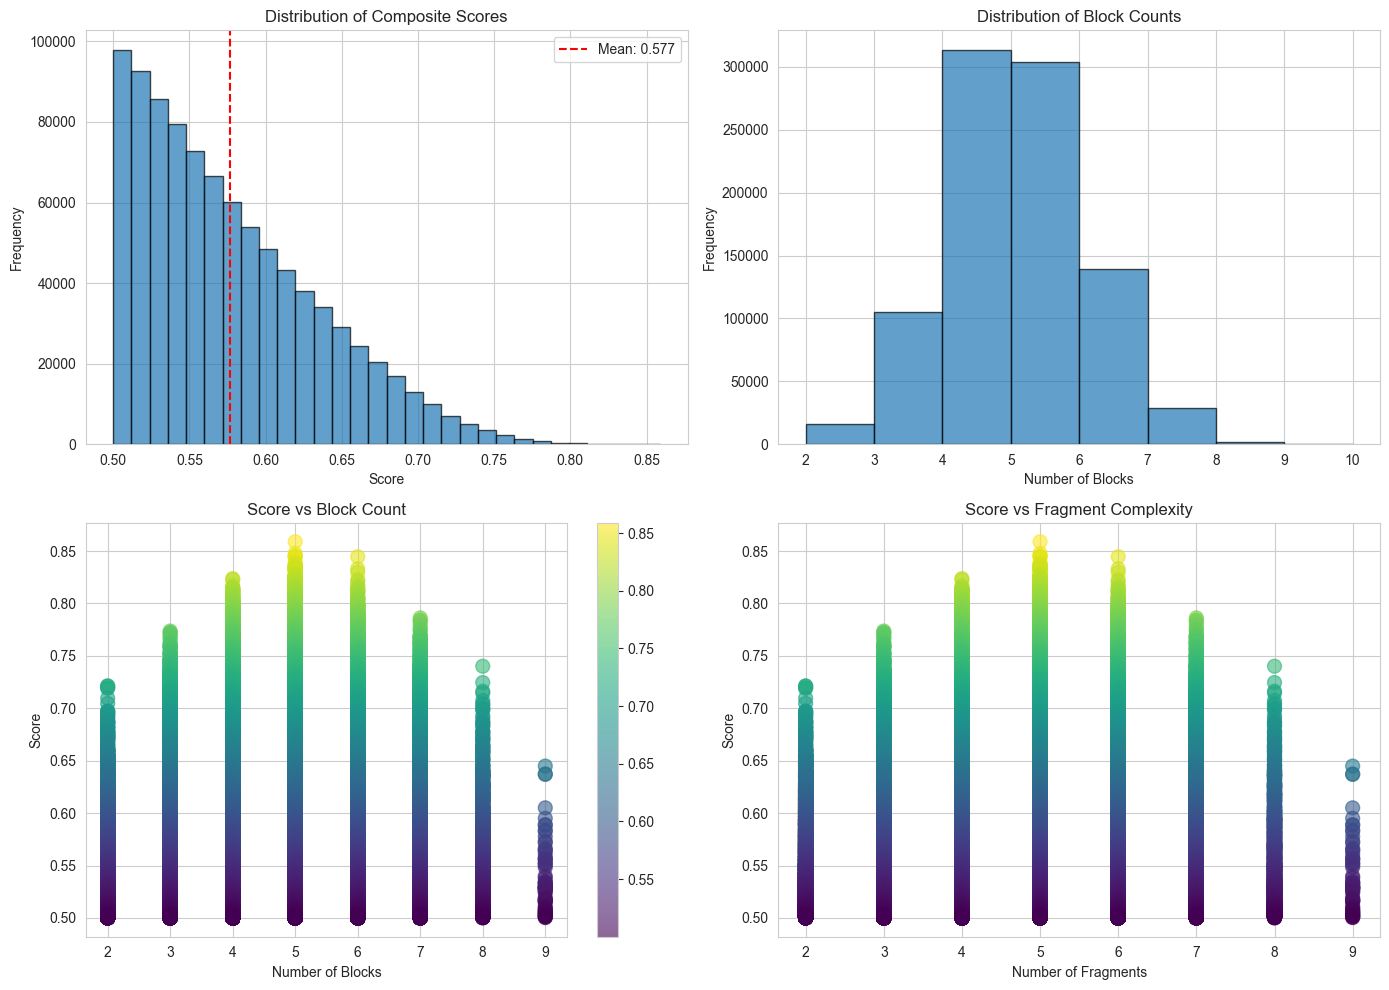

Visualization complete!


In [20]:
# Plot 1: Score distribution
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Score histogram
axes[0, 0].hist(results_df['score'], bins=30, edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('Score')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Distribution of Composite Scores')
axes[0, 0].axvline(results_df['score'].mean(), color='red', linestyle='--', label=f"Mean: {results_df['score'].mean():.3f}")
axes[0, 0].legend()

# Block count distribution
axes[0, 1].hist(results_df['n_blocks'], bins=range(int(results_df['n_blocks'].min()), int(results_df['n_blocks'].max()) + 2), edgecolor='black', alpha=0.7)
axes[0, 1].set_xlabel('Number of Blocks')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Distribution of Block Counts')

# Score vs block count scatter plot
scatter = axes[1, 0].scatter(results_df['n_blocks'], results_df['score'], alpha=0.6, c=results_df['score'], cmap='viridis', s=100)
axes[1, 0].set_xlabel('Number of Blocks')
axes[1, 0].set_ylabel('Score')
axes[1, 0].set_title('Score vs Block Count')
plt.colorbar(scatter, ax=axes[1, 0])

# Score vs fragment count (proxy for complexity)
axes[1, 1].scatter(results_df['fragment_ids'].apply(len), results_df['score'], alpha=0.6, c=results_df['score'], cmap='viridis', s=100)
axes[1, 1].set_xlabel('Number of Fragments')
axes[1, 1].set_ylabel('Score')
axes[1, 1].set_title('Score vs Fragment Complexity')

plt.tight_layout()
plt.show()

print("Visualization complete!")

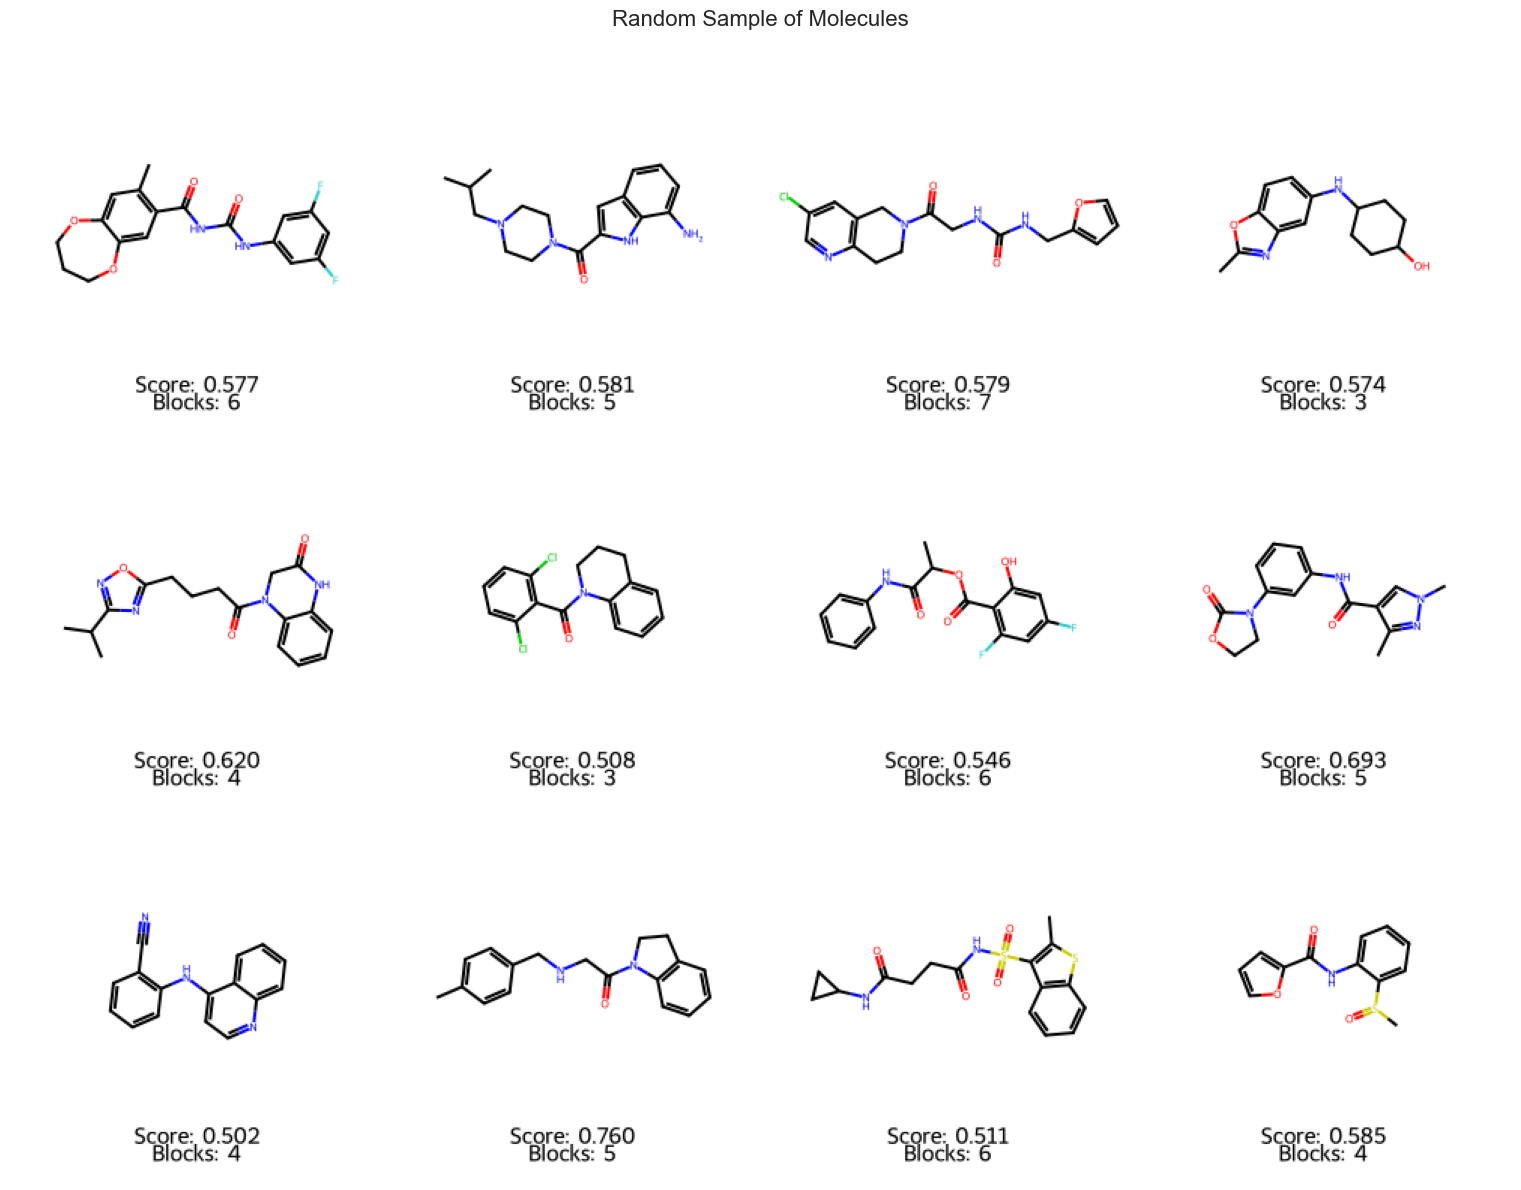

In [33]:
# Display 12 random molecule structures (or fewer if not enough results)
num_display = min(len(results_df), 12)
if num_display == 0:
    print("No molecules to display")
else:
    top_mols = results_df.sample(n=num_display)
    mols = []
    legends = []

    for idx, row in top_mols.iterrows():
        mol = Chem.MolFromSmiles(row['smiles'])
        if mol is not None:
            mols.append(mol)
            legends.append(f"Score: {row['score']:.3f}\nBlocks: {row['n_blocks']}")

    if mols:
        img = Draw.MolsToGridImage(
            mols,
            molsPerRow=4,
            subImgSize=(250, 250),
            legends=legends,
            returnPNG=False
        )
        plt.figure(figsize=(16, 12))
        plt.imshow(img)
        plt.axis('off')
        plt.title('Random Sample of Molecules', fontsize=16, pad=20)
        plt.tight_layout()
        plt.show()
    else:
        print("Warning: Could not generate molecule structures from SMILES strings")

In [22]:
def smi2cansmiles(smi: str) -> str | None:
    mol = Chem.MolFromSmiles(smi)
    return Chem.MolToSmiles(mol, canonical=True) if mol else None

canonical = Parallel(n_jobs=-1, backend="loky", batch_size=500)(  # pyright: ignore[reportArgumentType]
    delayed(smi2cansmiles)(smi) for smi in results_df['smiles']
)
results_df['canonical_smiles'] = canonical  # pyright: ignore[reportArgumentType, reportCallIssue]

canonical_results_path = Path("../data/processed") / "mcts_results_canonical.parquet"
results_df.to_parquet(canonical_results_path, index=False)
print(f"Saved canonicalized results to {canonical_results_path}")

Saved canonicalized results to ../data/processed/mcts_results_canonical.parquet


In [23]:
uniqueness_rate=len(results_df['canonical_smiles'].dropna().unique())/ len(results_df)
print(f"Uniqueness rate: {uniqueness_rate:.2%}")

Uniqueness rate: 83.84%


In [24]:
print(results_df.head())

                                           smiles     score  n_blocks  \
0  C1=C(-Br)-C=C-C(=C-1)NC(=O)C1=C-C=C(-C=C-1)O-C  0.858907         5   
1    C1-C(=C-C=C-C=1-Br)C(=O)NC1=C-C=C(-C=C-1)O-C  0.847727         5   
2  C1=C(-Br)-C(=C-C=C-1)C(=O)NC1=C-C=C(-C=C-1)O-C  0.844739         5   
3    C1-C=C-C=C(-C=1-Br)C(=O)NC1=C-C=C(-C=C-1)O-C  0.844739         5   
4    Br-C1-C(=C-C=C-C=1)C(=O)NC1=C-C=C(-C=C-1)O-C  0.844739         5   

                                        fragment_ids  \
0  [6_Brc1ccccc1_4, 0_N_0, 0_C=O_0, 0_c1ccccc1_3,...   
1  [2_Brc1ccccc1_3, 0_C=O_0, 0_N_0, 0_c1ccccc1_3,...   
2  [6_Brc1ccccc1_2, 0_C=O_0, 0_N_0, 0_c1ccccc1_3,...   
3  [2_Brc1ccccc1_6, 0_C=O_0, 0_N_0, 0_c1ccccc1_3,...   
4  [0_Brc1ccccc1_2, 0_C=O_0, 0_N_0, 0_c1ccccc1_3,...   

                 canonical_smiles  
0  COc1ccc(C(=O)Nc2ccc(Br)cc2)cc1  
1  COc1ccc(NC(=O)c2cccc(Br)c2)cc1  
2    COc1ccc(NC(=O)c2ccccc2Br)cc1  
3    COc1ccc(NC(=O)c2ccccc2Br)cc1  
4    COc1ccc(NC(=O)c2ccccc2Br)cc1  


In [25]:
moses_canonical_path = PROCESSED_DATA_DIR / "moses_canonical.parquet"
if moses_canonical_path.exists():
    moses_df = pd.read_parquet(moses_canonical_path)
    print(f"Loaded canonicalized MOSES dataset from {moses_canonical_path}")
else:   
    moses_df  = pd.read_csv("../data/external/moses_dataset.csv")

Loaded canonicalized MOSES dataset from /Users/ereboul/projects/smiles_blocks/data/processed/moses_canonical.parquet


In [26]:
canonical = Parallel(n_jobs=-1, backend="loky", batch_size=500)( # pyright: ignore[reportArgumentType]
    delayed(smi2cansmiles)(smi) for smi in moses_df['SMILES']
)
if "canonical_smiles" not in moses_df.columns:
    moses_df['canonical_smiles'] = canonical # pyright: ignore[reportArgumentType, reportCallIssue]
    
    moses_df.to_parquet(moses_canonical_path, index=False)
    print(f"Saved canonicalized MOSES dataset to {moses_canonical_path}")

In [27]:
novelty_rate=1-len(set(moses_df['canonical_smiles'].dropna()).intersection(set(results_df['canonical_smiles'].dropna())))/ len(results_df)
print(f"Novelty rate compared to MOSES dataset: {novelty_rate:.2%}")

Novelty rate compared to MOSES dataset: 95.78%


In [28]:
def compute_mol_properties(smi: str) -> dict | None:
    """
    Compute 8 molecular properties for a single SMILES string.

    Returns a dict with all properties, or None if the SMILES is invalid.

    Properties
    ----------
    mol_weight   : Molecular Weight (Da)
    crippen_logp : Crippen LogP
    hbd          : Number of Hydrogen Bond Donors
    hba          : Number of Hydrogen Bond Acceptors
    qed          : Quantitative Estimate of Drug-likeness [0, 1]
    sa_score     : Synthetic Accessibility Score [1, 10]
    rot_bonds    : Number of Rotatable Bonds
    tpsa         : Topological Polar Surface Area (Å²)
    """
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        return None
    try:
        return {
            "mol_weight":   Descriptors.MolWt(mol), # pyright: ignore[reportAttributeAccessIssue]
            "crippen_logp": Descriptors.MolLogP(mol), # pyright: ignore[reportAttributeAccessIssue]
            "hbd":          rdMolDescriptors.CalcNumHBD(mol),
            "hba":          rdMolDescriptors.CalcNumHBA(mol),
            "qed":          QED.qed(mol),
            "sa_score":     sascorer.calculateScore(mol),
            "rot_bonds":    rdMolDescriptors.CalcNumRotatableBonds(mol),
            "tpsa":         rdMolDescriptors.CalcTPSA(mol),
        }
    except Exception:
        return None

In [29]:
def compute_properties_df(
    smiles_series: pd.Series,
    n_jobs: int = -1,
    batch_size: int = 500,
) -> pd.DataFrame:
    """
    Compute molecular properties for a Series of SMILES strings in parallel.

    Parameters
    ----------
    smiles_series : pd.Series
        Column of SMILES strings (e.g. results_df['canonical_smiles']).
    n_jobs : int
        Number of parallel workers. -1 uses all available cores.
    batch_size : int
        Tasks per worker batch. 500 is a good default for large datasets.

    Returns
    -------
    pd.DataFrame
        One row per input SMILES (rows for invalid SMILES are dropped).
        Index is preserved from smiles_series.
    """
    results = Parallel(n_jobs=n_jobs, backend="loky", batch_size=batch_size)(
        delayed(compute_mol_properties)(smi)
        for smi in smiles_series
    )

    props_df = pd.DataFrame(
        [r for r in results if r is not None],
        index=[i for i, r in zip(smiles_series.index, results) if r is not None],
    )

    n_invalid = sum(1 for r in results if r is None)
    if n_invalid:
        print(f"  Skipped {n_invalid:,} invalid SMILES "
              f"({n_invalid / len(results) * 100:.1f}%)")

    return props_df

In [30]:

# Cache expensive property calculations so rerunning the notebook does not
# recompute RDKit descriptors when the SMILES input has not changed.
properties_cache_dir = PROCESSED_DATA_DIR / "mcts_property_cache"
properties_cache_dir.mkdir(parents=True, exist_ok=True)


def _series_cache_key(smiles_series: pd.Series) -> str:
    """Create a stable cache key from the SMILES content."""
    signature = pd.util.hash_pandas_object(
        smiles_series.fillna("").astype(str),
        index=False,
    ).sum()
    return f"{len(smiles_series)}_{int(signature)}"


def load_or_compute_properties_df(
    smiles_series: pd.Series,
    cache_prefix: str,
    n_jobs: int = -1,
    batch_size: int = 500,
) -> pd.DataFrame:
    """Load cached properties if available, otherwise compute and save them."""
    cache_key = _series_cache_key(smiles_series)
    cache_path = properties_cache_dir / f"{cache_prefix}_{cache_key}.parquet"

    if cache_path.exists():
        print(f"Loading cached properties from {cache_path}")
        return pd.read_parquet(cache_path)

    print(f"Computing properties for {cache_prefix}...")
    props_df = compute_properties_df(
        smiles_series,
        n_jobs=n_jobs,
        batch_size=batch_size,
    )
    props_df.to_parquet(cache_path)
    print(f"Saved cached properties to {cache_path}")
    return props_df


canonical_results_path = Path("../data/processed") / "mcts_results_canonical.parquet"
if "results_df" not in globals():
    if canonical_results_path.exists():
        results_df = pd.read_parquet(canonical_results_path)
    else:
        results_df = pd.read_csv("../data/processed/mcts_results.csv")
elif "canonical_smiles" not in results_df.columns:
    if canonical_results_path.exists():
        results_df = pd.read_parquet(canonical_results_path)
    else:
        results_df["canonical_smiles"] = [
            smi2cansmiles(smi) for smi in results_df["smiles"]
        ]

if "moses_df" not in globals():
    moses_df = pd.read_csv("../data/external/moses_dataset.csv")

# Compute or load the generated-molecule properties.
sample_props = load_or_compute_properties_df(
    results_df["canonical_smiles"],
    cache_prefix="generated_sample_props",
)

# Compute or load the MOSES reference properties.
moses_props = load_or_compute_properties_df(
    moses_df["SMILES"],
    cache_prefix="moses_reference_props",
)

# Save the final generated results with properties so later analysis can reuse it.
results_with_properties = results_df.join(sample_props, how="left", rsuffix="_prop")
results_with_properties_path = properties_cache_dir / f"results_with_properties_{_series_cache_key(results_df['canonical_smiles'])}.parquet"
if results_with_properties_path.exists():
    print(f"Final results with properties already exist at {results_with_properties_path}")
else:
    results_with_properties.to_parquet(results_with_properties_path)
    print(f"Saved final results with properties to {results_with_properties_path}")


Computing properties for generated_sample_props...
Saved cached properties to /Users/ereboul/projects/smiles_blocks/data/processed/mcts_property_cache/generated_sample_props_907818_2087290814608336221.parquet
Loading cached properties from /Users/ereboul/projects/smiles_blocks/data/processed/mcts_property_cache/moses_reference_props_1936962_16496303602004351570.parquet
Saved final results with properties to /Users/ereboul/projects/smiles_blocks/data/processed/mcts_property_cache/results_with_properties_907818_2087290814608336221.parquet


In [31]:
CONTINUOUS = [
    ("mol_weight",   "Molecular Weight (Da)"),
    ("crippen_logp", "Crippen LogP"),
    ("qed",          "QED"),
    ("sa_score",     "SA Score"),
    ("tpsa",         "TPSA (Å²)"),
]
DISCRETE = [
    ("hbd",       "H-Bond Donors"),
    ("hba",       "H-Bond Acceptors"),
    ("rot_bonds", "Rotatable Bonds"),
]

MOSES_COLOR  = "#1f77b4"
SAMPLE_COLOR = "#ff7f0e"
KDE_PTS      = 400


def _kde_plot(ax, values, color, lo, hi):
    """KDE filled curve for a continuous variable."""
    v = values[np.isfinite(values)]
    if len(v) < 10:
        return
    pad = (hi - lo) * 0.04
    x   = np.linspace(lo - pad, hi + pad, KDE_PTS)
    y   = gaussian_kde(v, bw_method="scott")(x)
    ax.plot(x, y, color=color, linewidth=2.0)
    ax.fill_between(x, y, alpha=0.15, color=color)


def _count_plot(ax, values, color, bins):
    """
    Normalised count bars for a discrete variable.
    Uses step-style histograms so both datasets overlay cleanly.
    """
    v = values[np.isfinite(values)].astype(int)
    counts = np.bincount(v - bins[0], minlength=len(bins))
    freq   = counts / counts.sum()
    width  = 0.38
    offsets = np.array(bins) - width / 2 if color == MOSES_COLOR else np.array(bins) + width / 2
    ax.bar(offsets, freq[:len(bins)], width=width,
           color=color, alpha=0.75, edgecolor="white", linewidth=0.4)


def plot_property_panel(
    moses_props: "pd.DataFrame",
    sample_props: "pd.DataFrame",
    figsize: tuple = (15, 9),
    save_path: str | None = None,
) -> "plt.Figure":
    """
    3x3 panel figure comparing MOSES vs generated molecule property distributions.

    Continuous variables (mol_weight, crippen_logp, qed, sa_score, tpsa)
    are shown as overlaid KDE curves.  Discrete variables (hbd, hba,
    rot_bonds) are shown as side-by-side normalised bar charts.
    The 9th panel holds the shared legend.

    Parameters
    ----------
    moses_props  : pd.DataFrame  Output of compute_properties_df(moses_df['SMILES'])
    sample_props : pd.DataFrame  Output of compute_properties_df(results_df['canonical_smiles'])
    figsize      : tuple         Figure size (default 15x9 inches)
    save_path    : str | None    If provided, save the figure to this path

    Returns
    -------
    matplotlib.figure.Figure
    """
    fig, axes = plt.subplots(3, 3, figsize=figsize)
    fig.patch.set_facecolor("white")

    all_props = CONTINUOUS + DISCRETE
    n_total   = len(all_props)           # 8 panels + 1 legend

    for idx, (key, title) in enumerate(all_props):
        ax  = axes[idx // 3][idx % 3]
        ax.set_facecolor("white")
        ax.spines[["top", "right"]].set_visible(False)
        ax.tick_params(labelsize=8)

        m = moses_props[key].dropna().values  if key in moses_props.columns  else np.array([])
        s = sample_props[key].dropna().values if key in sample_props.columns else np.array([])

        if len(m) == 0 and len(s) == 0:
            ax.set_visible(False)
            continue

        is_discrete = key in {k for k, _ in DISCRETE}

        if is_discrete:
            all_vals = np.concatenate([m, s]).astype(int)
            lo, hi   = int(all_vals.min()), int(all_vals.max())
            bins     = list(range(lo, min(hi + 1, lo + 20)))   # cap at 20 ticks

            _count_plot(ax, m, MOSES_COLOR,  bins)
            _count_plot(ax, s, SAMPLE_COLOR, bins)

            ax.set_xlim(lo - 1, bins[-1] + 1)
            ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
            ax.set_ylabel("Frequency", fontsize=9)

        else:
            all_vals = np.concatenate([m, s])
            lo = np.percentile(all_vals[np.isfinite(all_vals)], 0.5)
            hi = np.percentile(all_vals[np.isfinite(all_vals)], 99.5)

            _kde_plot(ax, m, MOSES_COLOR,  lo, hi)
            _kde_plot(ax, s, SAMPLE_COLOR, lo, hi)

            pad = (hi - lo) * 0.04
            ax.set_xlim(lo - pad, hi + pad)
            ax.set_ylim(bottom=0)
            ax.set_ylabel("Density", fontsize=9)

        ax.set_title(title, fontsize=10, pad=5)

    # ── Legend in the 9th cell ────────────────────────────────────────────────
    ax_leg = axes[2][2]
    ax_leg.set_visible(False)
    leg_ax = fig.add_axes([0.68, 0.06, 0.22, 0.20])
    leg_ax.set_axis_off()
    handles = [
        Line2D([0], [0], color=MOSES_COLOR,  linewidth=3, label="MOSES"),
        Line2D([0], [0], color=SAMPLE_COLOR, linewidth=3, label="Generated molecules"),
    ]
    leg = leg_ax.legend(
        handles=handles, title="Dataset",
        title_fontsize=10, fontsize=9,
        loc="center", frameon=True,
        framealpha=0.85, edgecolor="#cccccc",
    )
    leg.get_frame().set_linewidth(0.6)

    fig.tight_layout(rect=[0, 0, 1, 1])

    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches="tight", facecolor="white")
        print(f"Saved: {save_path}")

    return fig

/var/folders/3y/7l0sjs0s3p5980563tk_fm3h0000gp/T/ipykernel_69227/559920453.py:135: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 1, 1])


Saved: /Users/ereboul/projects/smiles_blocks/reports/figures/mcts/property_distributions_comparison.svg


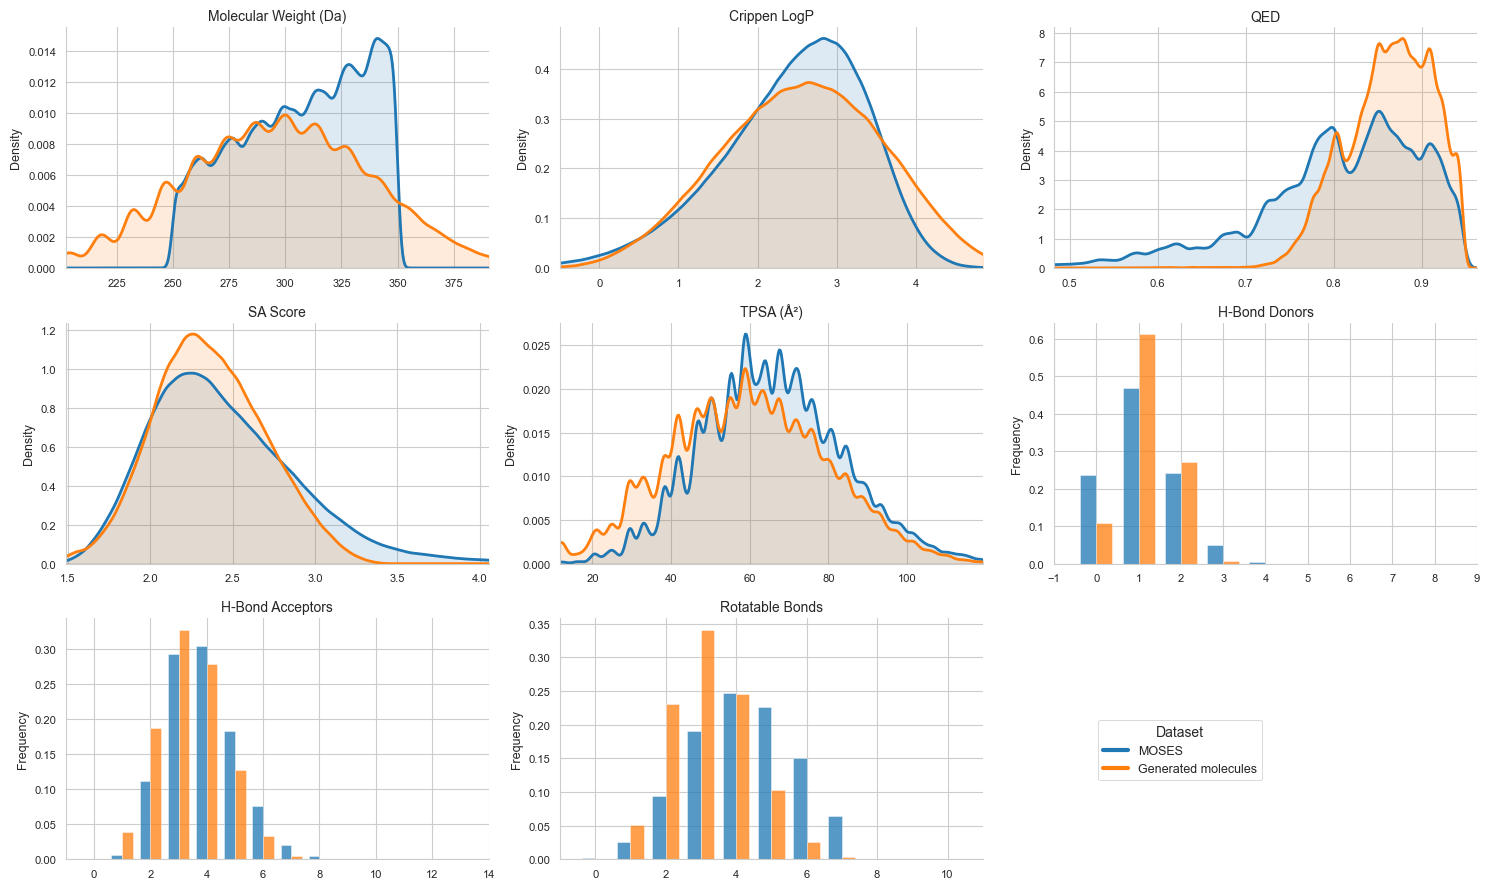

In [32]:
fig_dir = FIGURES_DIR / "mcts"
fig_dir.mkdir(parents=True, exist_ok=True)

fig = plot_property_panel(
    moses_props  = moses_props,
    sample_props = sample_props,
    figsize      = (15, 9),
    save_path    = str(fig_dir / "property_distributions_comparison.svg"),   # or None
)
plt.show()